# SCCs of the full interaction graph (October 2026 model)

`02_structural_scc_analysis` decomposes only the subnetwork of nodes that cycle inside one
attractor class. This notebook does the same decomposition on the **whole** interaction graph of
`model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.bnet`, with no attractor and no input fixed.

A **strongly connected component** (SCC) is a maximal set of nodes in which every node can reach
every other. Every feedback loop lies entirely inside one SCC. A node outside every non-trivial SCC
is on no loop and only relays signals. A **non-trivial** SCC has more than one node or a self-loop.

Steps:

1. Build the signed interaction graph from the rules.
2. Decompose it into SCCs.
3. Place every other node relative to the SCCs: upstream, downstream or unrelated.
4. Count the feedback loops of each SCC by length and sign.
5. Draw the network coloured by SCC.

In [1]:
import os
import xml.etree.ElementTree as ET
import zipfile
from pathlib import Path

import biodivine_aeon as ba
import networkx as nx
import pandas as pd
import pygraphviz as pgv
from IPython.display import Image

if not Path("model").exists():          # repo root, as in the other notebooks of this folder
    os.chdir("../../../../")
pd.set_option("display.max_colwidth", None)

BNET_PATH = Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.bnet")
ZGINML_PATH = Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.zginml")
READOUTS = ["Proliferation", "Autop_digestion", "Apoptosis", "BECN1", "Senescence"]

## 1 — The signed interaction graph

One edge per regulation, with sign `+` (activation) or `-` (inhibition) inferred from the rules by
AEON. Inputs are written `X, X` in the `.bnet`, so each input carries a positive self-loop.

In [2]:
def signed_graph(bn):
    g = nx.DiGraph()
    g.add_nodes_from(bn.variable_names())
    for r in bn.regulations():
        g.add_edge(bn.get_variable_name(r["source"]), bn.get_variable_name(r["target"]),
                   sign=str(r["sign"]))
    return g

full = signed_graph(ba.BooleanNetwork.from_file(str(BNET_PATH)).infer_valid_graph())
signs = pd.Series([s for *_, s in full.edges(data="sign")]).value_counts()
pd.Series({"nodes": full.number_of_nodes(), "edges": full.number_of_edges(),
           "activations (+)": signs.get("+", 0), "inhibitions (-)": signs.get("-", 0)},
          name=BNET_PATH.stem).to_frame().T

,nodes,edges,activations (+),inhibitions (-)
Autophagy_and_apoptosis_Sept26_2026-10-01,125,216,155,61


## 2 — SCC decomposition

All SCCs first, then the non-trivial ones with their feedback loops. A loop is **negative** when it
has an odd number of inhibitions (needed for sustained oscillation, Thomas' rule) and **positive**
otherwise (needed for multistability).

In [3]:
def loop_sign(g, loop):
    return "-" if sum(g[a][b]["sign"] == "-" for a, b in zip(loop, loop[1:] + loop[:1])) % 2 else "+"

sccs = sorted(nx.strongly_connected_components(full), key=len, reverse=True)
nontrivial = [s for s in sccs if len(s) > 1 or full.has_edge(*[next(iter(s))] * 2)]
loops = {id(s): list(nx.simple_cycles(full.subgraph(s))) for s in nontrivial}

print(f"{len(sccs)} SCCs in total, {len(nontrivial)} non-trivial, "
      f"{len(sccs) - len(nontrivial)} single nodes on no loop")
pd.DataFrame([{"nodes": len(s), "internal edges": full.subgraph(s).number_of_edges(),
               "loops": len(loops[id(s)]),
               "negative loops": sum(loop_sign(full, c) == "-" for c in loops[id(s)]),
               "positive loops": sum(loop_sign(full, c) == "+" for c in loops[id(s)]),
               "members": ", ".join(sorted(s))} for s in nontrivial])

53 SCCs in total, 8 non-trivial, 45 single nodes on no loop


,nodes,internal edges,loops,negative loops,positive loops,members
0,73,121,4350,2257,2093,"AKT1, AMBRA1, ATG13, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, Autophagy, Autophagy_sustained, BAX, BBC3, BCL2, BCL2L11, BCL2_BECN1_C, BECN1, BID, CASP8, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, FKBP8, FLIP, FOXO, GSK3A, H2O2, IKBKB, IRS1, KEAP1, MAP1LC3A_II, MDM2, MOMP, MON1A, MTOR, MTOR_C2, NEDD4, NFE2L2, NFKBIA, NFkappaB, NQO1, PARK2, PDGFRA, PI3P, PIK3C3, PIK3CA, PINK1, PPP2R, PRKA, PTEN, RAB7A, RB1CC1, RHEB, RHOA, ROCK, RPS6KB1, RPTOR, RRAGA, SP1, SP1_sustained, SQSTM1, TP53_cyto, TP53_nuc, TRAF6, TSC2, ULK1, UVRAG, Ulk_C, WIPI_1, YWHAB, mRNA_BBC3, mRNA_BCL2L11, mRNA_SP1"
1,1,1,1,0,1,AA_Starvation
2,1,1,1,0,1,DNA_damage
3,1,1,1,0,1,Glucose_starv
4,1,1,1,0,1,Growth_factor
5,1,1,1,0,1,Insuline
6,1,1,1,0,1,O_stress
7,1,1,1,0,1,TNF_R_or_DR


The 125-node graph splits into 53 SCCs, but only 8 are non-trivial:

* **one core SCC of 73 nodes** that holds every feedback loop of the model (4350 loops, 2257
  negative and 2093 positive). It spans the AMPK (`PRKA`)–ULK1–MTOR module, PI3K/AKT, the
  autophagy cascade from `BECN1` to `Autop_digestion` and `Autophagy_sustained`, the p62 branch
  (`SQSTM1`, `KEAP1`, `NQO1`, `NFE2L2`), the BCL2 family, MOMP and the caspases, NF-κB and p53;
* **seven input self-loops**: `AA_Starvation`, `DNA_damage`, `Glucose_starv`, `Growth_factor`,
  `Insuline`, `O_stress`, `TNF_R_or_DR`.

The remaining 45 nodes are on no loop.

## 3 — Where the other nodes sit

Each node outside the core SCC is classified by its reachability to the core:

* **input**: a self-loop only (`X, X` in the `.bnet`);
* **constant**: no regulator at all (rule `0` or `1`);
* **upstream**: reaches the core;
* **downstream**: reached from the core;
* **unrelated**: neither (it can still be connected to the core through an input).

In [4]:
core = nontrivial[0]
inputs = {v for v in full if set(full.predecessors(v)) == {v}}
constants = {v for v in full if full.in_degree(v) == 0}
core_ancestors = set().union(*(nx.ancestors(full, v) for v in core)) - core
core_descendants = set().union(*(nx.descendants(full, v) for v in core)) - core

def role(v):
    if v in core: return "core SCC"
    if v in inputs: return "input"
    if v in constants: return "constant"
    if v in core_ancestors: return "upstream"
    if v in core_descendants: return "downstream"
    return "unrelated"

roles = pd.Series({v: role(v) for v in full}, name="role")
ORDER = ["input", "constant", "upstream", "core SCC", "downstream", "unrelated"]
(roles.groupby(roles).agg(nodes="size", members=lambda s: ", ".join(sorted(s.index)))
      .reindex([r for r in ORDER if r in set(roles)]))

,nodes,members
role,,
input,7,"AA_Starvation, DNA_damage, Glucose_starv, Growth_factor, Insuline, O_stress, TNF_R_or_DR"
upstream,30,"ATF4, ATM, CAMKKB, CHOP, CHOP_sustained, Ca_cyto, DAPK1, EGFR, EIF2AK3, ER_stress, GAB, GRB2, IP3R, IP3R_VDAC, IRE1, JIP, Kinesin_1, MAP3K, MAPK8, Mito_overcharge, PRKD1, RAS, ROMO1, SOS, STK11, Tubulin, mRNA_ATF4, mRNA_BCL2, mRNA_CHOP, mRNA_ROMO1"
core SCC,73,"AKT1, AMBRA1, ATG13, ATG14, ATG3, Atg16L_Atg5_Atg12, Atphgo_form, Atphgo_mat, Autop_digestion, Autophagy, Autophagy_sustained, BAX, BBC3, BCL2, BCL2L11, BCL2_BECN1_C, BECN1, BID, CASP8, Caspase9_APAF1_C, Caspase_3_6_7_C, Cyt_C, FKBP8, FLIP, FOXO, GSK3A, H2O2, IKBKB, IRS1, KEAP1, MAP1LC3A_II, MDM2, MOMP, MON1A, MTOR, MTOR_C2, NEDD4, NFE2L2, NFKBIA, NFkappaB, NQO1, PARK2, PDGFRA, PI3P, PIK3C3, PIK3CA, PINK1, PPP2R, PRKA, PTEN, RAB7A, RB1CC1, RHEB, RHOA, ROCK, RPS6KB1, RPTOR, RRAGA, SP1, SP1_sustained, SQSTM1, TP53_cyto, TP53_nuc, TRAF6, TSC2, ULK1, UVRAG, Ulk_C, WIPI_1, YWHAB, mRNA_BBC3, mRNA_BCL2L11, mRNA_SP1"
downstream,13,"Apoptosis, Cell_cycle, EIF4E, EIF4EBP1, Lysosome_prod, MAP2K1, MYC, Proliferation, Senescence, TFEB, p21, p21_sustained, pRB"
unrelated,2,"CDKN2A, RAF"


In [5]:
roles[[r for r in READOUTS if r in full]].to_frame()   # Senescence exists only from the October model

,role
Proliferation,downstream
Autop_digestion,core SCC
Apoptosis,downstream
BECN1,core SCC
Senescence,downstream


The network is a **bow-tie**: 30 upstream nodes (ER stress/UPR, Ca²⁺, RAS–EGFR, the JNK branch
`MAP3K`–`MAPK8`, `STK11`) feed the core, and 13 downstream nodes read it out. Of the readouts,
`BECN1` and `Autop_digestion` are inside the core, while `Apoptosis`, `Proliferation` and
`Senescence` are downstream: no readout node feeds back. `RAF` and `CDKN2A` are unrelated: they
are regulated only by upstream nodes (`RAS`, `ATM`) and regulate only downstream ones.

There are no constant nodes any more: `KEAP1 = !SQSTM1` and `NQO1 = NFE2L2` are now inside the
core. Pinning them to 1 as in the shared scenario convention therefore overrides a feedback loop
in this model, and is no longer just setting a constant.

## 4 — Feedback loops of the core SCC by length and sign

In [6]:
core_loops = pd.DataFrame([{"length": len(c), "sign": loop_sign(full, c)} for c in loops[id(core)]])
pd.crosstab(core_loops["length"], core_loops["sign"], margins=True, margins_name="total")

sign,+,-,total
length,,,
2,0,2,2
3,2,2,4
4,1,1,2
5,1,1,2
6,0,3,3
7,2,3,5
8,7,4,11
9,5,7,12
10,8,11,19


The shortest loops, with the inhibitions marked `⊣`:

In [7]:
def loop_string(g, loop):
    i = loop.index(min(loop))
    path = loop[i:] + loop[:i] + [loop[i]]
    return path[0] + "".join((" → " if g[a][b]["sign"] == "+" else " ⊣ ") + b
                             for a, b in zip(path, path[1:]))

pd.DataFrame([{"length": len(c), "sign": loop_sign(full, c), "loop": loop_string(full, c)}
              for c in loops[id(core)] if len(c) <= 3]).sort_values(["length", "sign"], ignore_index=True)

,length,sign,loop
0,2,-,PRKA → ULK1 ⊣ PRKA
1,2,-,BCL2_BECN1_C ⊣ BECN1 → BCL2_BECN1_C
2,3,+,NEDD4 ⊣ PTEN ⊣ PIK3CA → NEDD4
3,3,+,AKT1 ⊣ FOXO → PPP2R ⊣ AKT1
4,3,-,AKT1 ⊣ TSC2 → MTOR_C2 → AKT1
5,3,-,MOMP → PINK1 → PARK2 ⊣ MOMP


Negative and positive loops are about equally frequent overall, and most loops are long (median
length 25) because they cross the whole core. The two shortest negative loops are the
AMPK–ULK1 loop (`PRKA → ULK1 ⊣ PRKA`) and the BCL2 sequestration of BECN1. There is no 2-node
positive loop.

## 5 — The network coloured by SCC

The whole interaction graph, drawn with the node positions saved in the GINsim file (`.zginml`)
and with a hierarchical (graphviz `dot`) layout.

* **filled blue**: core SCC; **outlined blue**: upstream; **outlined orange**: downstream;
  **grey**: inputs, constants and unrelated nodes.
* An edge inside the core SCC is coloured (green = activation, red = inhibition); every other edge
  is faded.

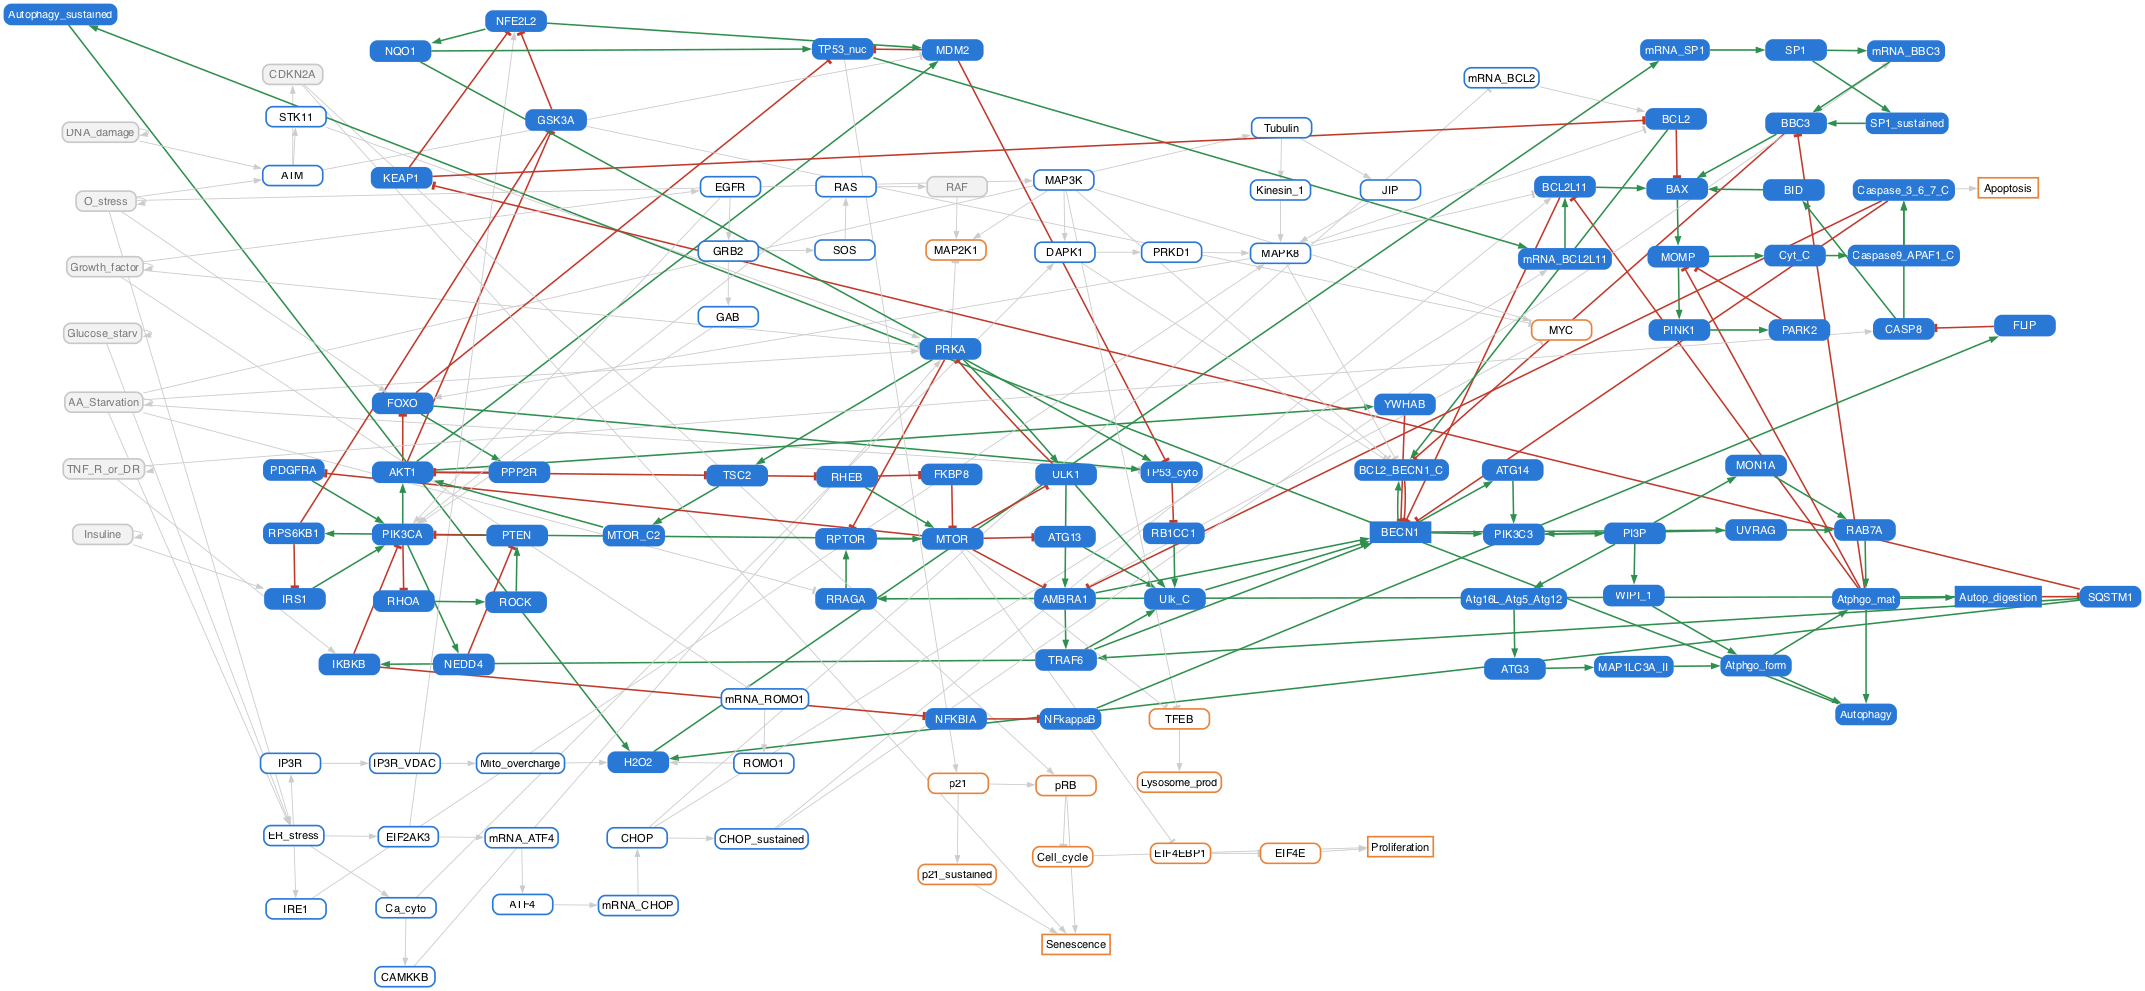

In [8]:
with zipfile.ZipFile(ZGINML_PATH) as z:
    root = ET.fromstring(z.read("GINsim-data/regulatoryGraph.ginml"))
ginsim_pos = {n.get("id"): (float(v.get("x")), float(v.get("y")))
              for n in root.iter("node") for v in n.iter("nodevisualsetting")}
assert set(ginsim_pos) == set(full)

NODE_STYLE = {"core SCC": dict(fillcolor="#2a78d6", color="#2a78d6", fontcolor="white"),
              "upstream": dict(fillcolor="white", color="#2a78d6", fontcolor="black"),
              "downstream": dict(fillcolor="white", color="#e8833a", fontcolor="black")}
OTHER_STYLE = dict(fillcolor="#f2f2f2", color="#c8c8c8", fontcolor="#7a7a7a")

def draw_full_network(layout):
    A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.12", ranksep="0.3", outputorder="edgesfirst")
    A.node_attr.update(shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10",
                       height="0.25", margin="0.05,0.02", penwidth="1.5")
    for v in full:
        attrs = dict(NODE_STYLE.get(roles[v], OTHER_STYLE))
        if v in READOUTS:
            attrs["style"] = "filled"               # square corners mark the readouts
        if layout == "ginsim":                      # GINsim y axis points down, graphviz y points up
            x, y = ginsim_pos[v]
            attrs["pos"] = f"{0.9 * x:.0f},{-0.9 * y:.0f}!"
        A.add_node(v, **attrs)
    for a, b in full.edges:
        positive = full[a][b]["sign"] == "+"
        inside = a in core and b in core
        A.add_edge(a, b, color=("#2f8f4e" if positive else "#c0392b") if inside else "#cccccc",
                   penwidth="1.4" if inside else "0.8", arrowhead="normal" if positive else "tee",
                   arrowsize="0.6")
    if layout == "ginsim":                          # keep the saved positions, straight edges
        return Image(A.draw(format="png", prog="neato", args="-n2 -Gsplines=line -Gdpi=80"))
    return Image(A.draw(format="png", prog="dot", args="-Gdpi=80"))

draw_full_network("ginsim")

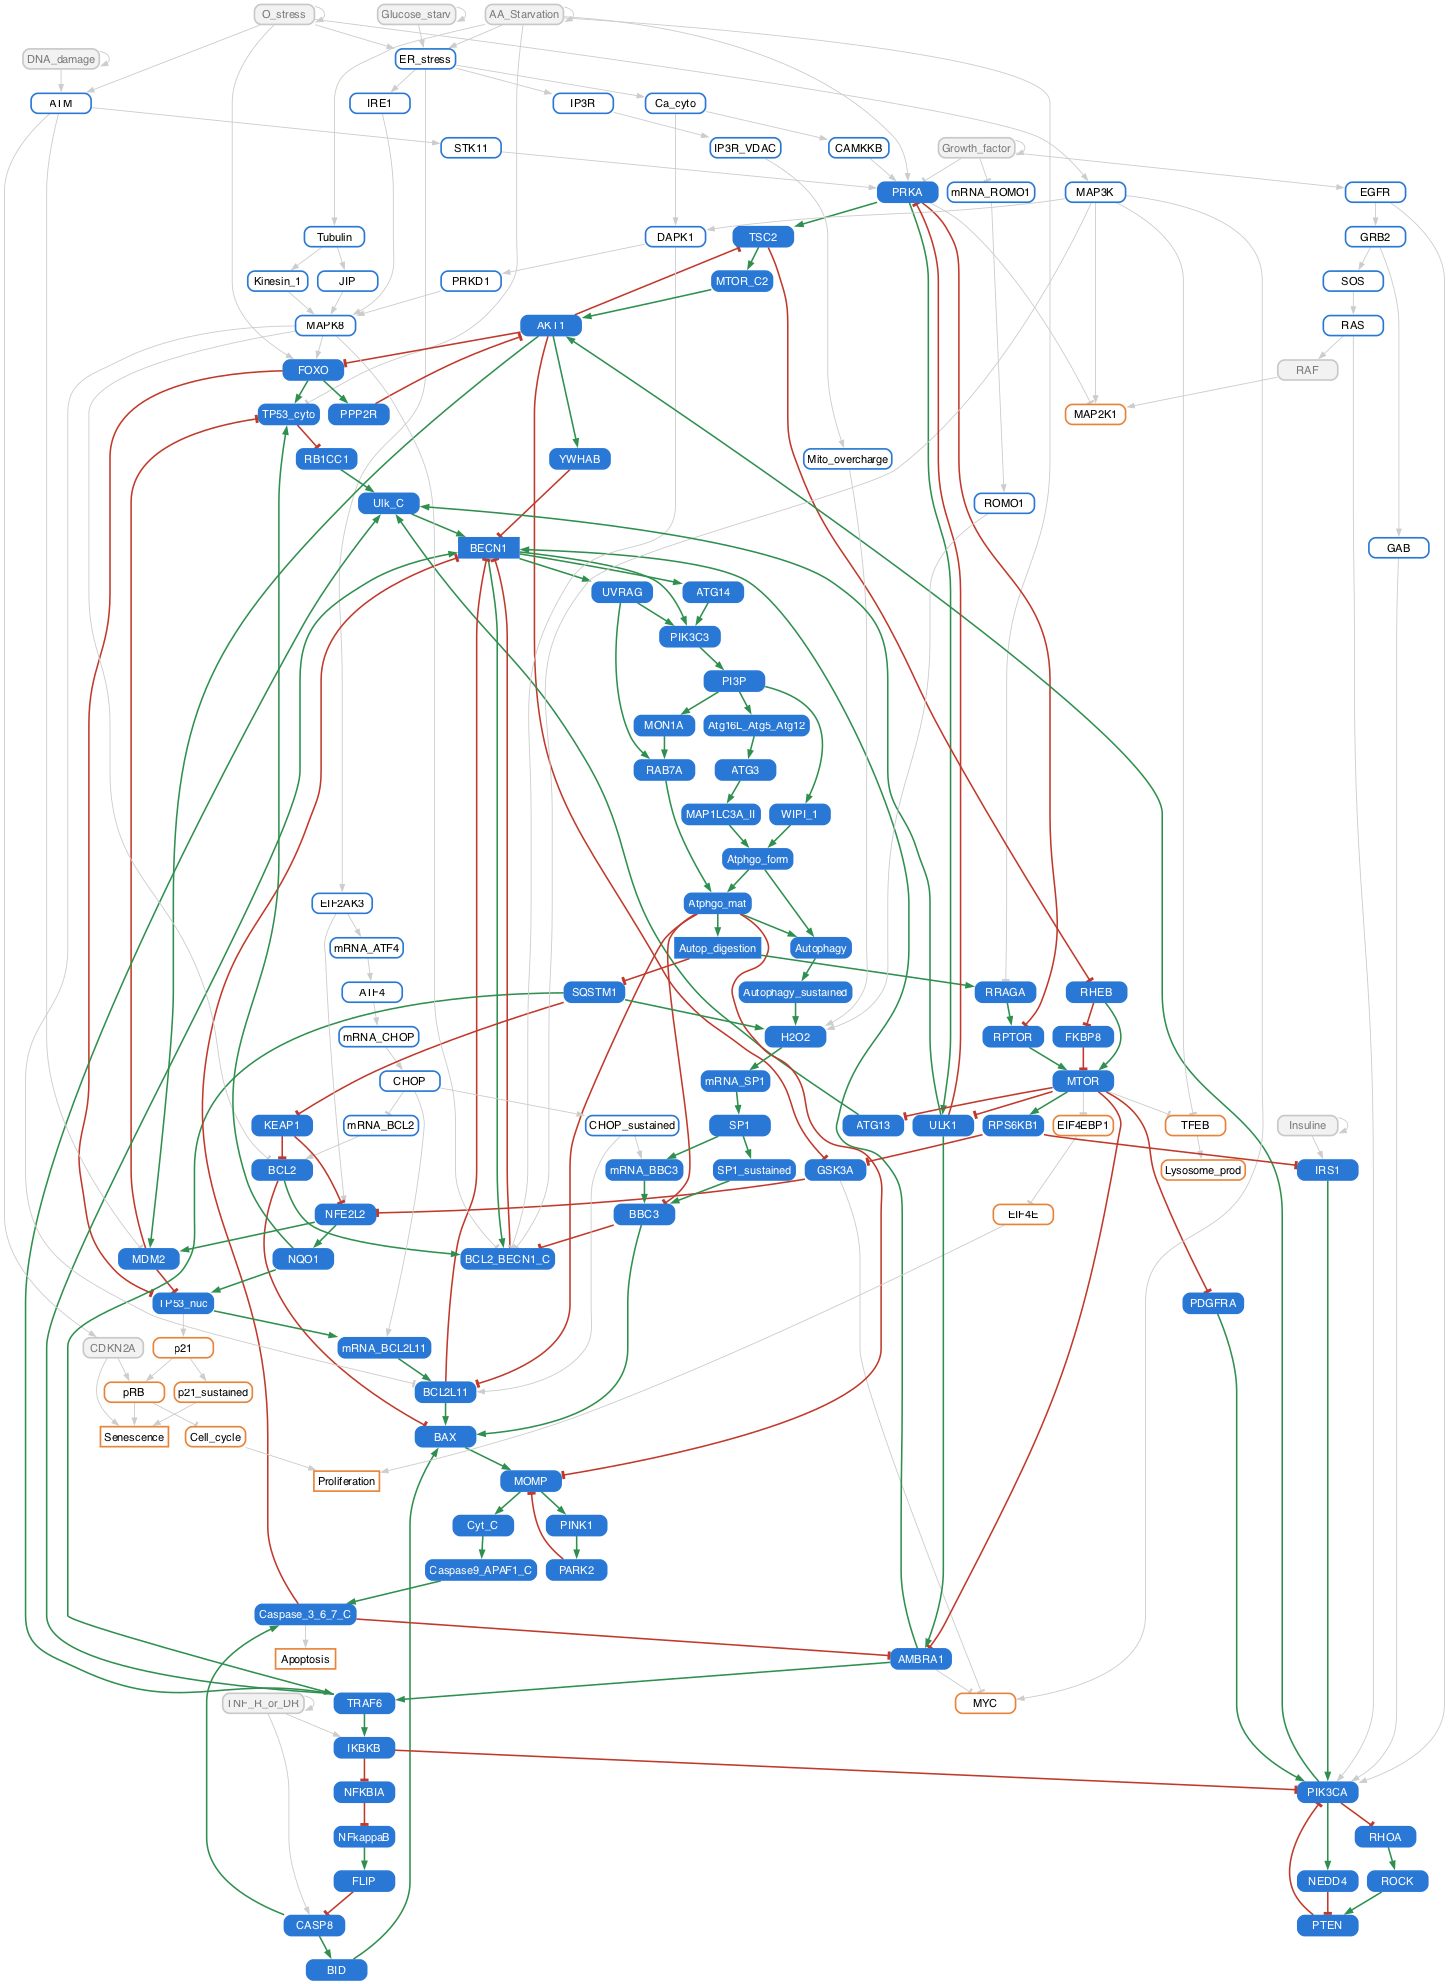

In [9]:
draw_full_network("hierarchical")

## 6 — Comparison with the September 2026 model

The same decomposition on `model/autophagy_september26/Autophagy_and_apoptosis_Sept26.bnet`, to see
which nodes joined or left the core SCC in this revision.

In [10]:
SEPT_PATH = Path("model/autophagy_september26/Autophagy_and_apoptosis_Sept26.bnet")
sept = signed_graph(ba.BooleanNetwork.from_file(str(SEPT_PATH)).infer_valid_graph())
sept_core = max(nx.strongly_connected_components(sept), key=len)

pd.Series({"core SCC size (Sept26 → Oct26)": f"{len(sept_core)} → {len(core)}",
           "new nodes in the model": ", ".join(sorted(set(full) - set(sept))),
           "nodes removed from the model": ", ".join(sorted(set(sept) - set(full))),
           "joined the core SCC": ", ".join(sorted(core - sept_core)),
           "left the core SCC": ", ".join(sorted(sept_core - core)),
           "core loops (Sept26 → Oct26)":
               f"{sum(1 for _ in nx.simple_cycles(sept.subgraph(sept_core)))} → {len(loops[id(core)])}"},
          name="").to_frame()

,
core SCC size (Sept26 → Oct26),68 → 73
new nodes in the model,"Autophagy, Autophagy_sustained, CDKN2A, DNA_damage, SQSTM1, Senescence, p21_sustained"
nodes removed from the model,AHSA1
joined the core SCC,"Autophagy, Autophagy_sustained, H2O2, KEAP1, NQO1, SP1, SP1_sustained, SQSTM1, mRNA_BBC3, mRNA_SP1"
left the core SCC,"DAPK1, MAP2K1, MAP3K, MAPK8, PRKD1"
core loops (Sept26 → Oct26),1914 → 4350


* **Joined the core**: the p62 loop. `SQSTM1 = !Autop_digestion` regulates `KEAP1` (`= !SQSTM1`,
  constant `0` before) and, through `H2O2`, `mRNA_SP1`/`SP1` and `mRNA_BBC3`, the apoptotic
  machinery; `NQO1 = NFE2L2` is no longer constant either. The new `Autophagy` /
  `Autophagy_sustained` nodes close back through `H2O2`.
* **Left the core**: the JNK branch. In September `PRKA → MAP2K1 → MAP3K` closed a loop through
  `DAPK1`, `PRKD1` and `MAPK8`. Now `MAP3K = O_stress`, so that branch is only upstream and
  `MAP2K1` only downstream.
* `UVRAG = BECN1` (was `PIK3C3`), which removes the 2-node positive loop `PIK3C3 → UVRAG`.

The core loop count more than doubles (1914 → 4350), mostly through long loops that pass through
the new p62 branch.

## Summary

* All feedback of the October 2026 model sits in **one 73-node SCC** (4350 loops, 2257 negative);
  every other non-trivial SCC is an input self-loop.
* The core contains `BECN1` and `Autop_digestion`; `Apoptosis`, `Proliferation` and `Senescence`
  are downstream of it, and 30 nodes, mostly stress sensors, are upstream.
* Compared with September, the p62–KEAP1–NRF2 branch entered the core and the JNK branch left it.
  `KEAP1` and `NQO1` are no longer constants, so pinning them in the scenarios now cuts a loop.
* Since the structure alone gives a single SCC, separating the oscillators needs the
  attractor-restricted analysis of `02_structural_scc_analysis`, where fixed nodes cut the core
  into smaller SCCs.